In [9]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [11]:
load_dotenv()
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small", dimensions=1024)

In [12]:
loader=PyPDFLoader("intro-to-ml.pdf")
docs=loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits = text_splitter.split_documents(docs)
print(f"Number of chunks: {len(splits)}")
vector_store = FAISS.from_documents(splits, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 3},search_type="similarity")

Number of chunks: 973


In [15]:
@tool(
    "rag_tools",
    description="A tool to retrieve relevant information from the PDF document based on the user's query. It returns the relevant context and metadata for the query."
)
def rag_tools(query: str) -> str:
    relevant_docs = retriever.invoke(query)

    context=[doc.page_content for doc in relevant_docs]
    metadata=[doc.metadata for doc in relevant_docs]
    return {
        "query": query,
        "context": context,
        "metadata": metadata
    }

In [16]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [17]:
tools=[rag_tools]
llm_with_tools = llm.bind_tools(tools)

In [18]:
def chat_node(state: ChatState) -> str:
    response = llm.invoke(state["messages"])
    return {
        "messages": [response]
}
tool_node = ToolNode(tools)

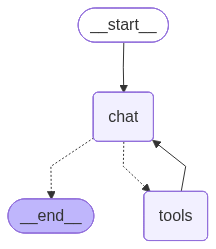

In [26]:
graph = StateGraph(ChatState)
graph.add_node("chat", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat")
graph.add_conditional_edges("chat", tools_condition)
graph.add_edge("tools", "chat")
graph.compile()


In [29]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)
print(result["messages"][-1].content)

To find the ideal value of K in KNN (K-Nearest Neighbors), we can use a technique called cross-validation. Cross-validation involves splitting the dataset into multiple subsets, training the model on a portion of the data, and then testing it on the remaining portion. This process is repeated multiple times with different splits of the data.

One common method of cross-validation is k-fold cross-validation, where the dataset is divided into k subsets (or folds). The model is trained on k-1 folds and tested on the remaining fold. This process is repeated k times, with each fold serving as the test set once. The average performance of the model across all k folds is then calculated.

To find the ideal value of K in KNN using cross-validation, we can perform the following steps:

1. Choose a range of values for K that you want to test (e.g., K=1 to K=10).
2. Divide the dataset into k folds.
3. For each value of K in the chosen range:
   a. Train the KNN model on k-1 folds.
   b. Test the 